# Project Management Dashboard - System Architecture

**Comprehensive visualization of the Project Management Dashboard system model**

This notebook provides in-depth visualizations of:
- Stakeholders and their requirements
- Capabilities and their dependencies
- Entities and their roles
- Process flows and data flows
- System architecture diagrams and visualizations

## Setup and Imports

In [1]:
import sys
sys.path.append('/mnt/project')
from utilities import dataframe, extract_id, todict, tolists, diagram, union
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch, Rectangle
import seaborn as sns
import networkx as nx
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')

# Set beautiful style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 10
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.titleweight'] = 'bold'

# Define consistent color scheme
COLORS = {
    'stakeholder': '#FF6B6B',
    'requirement': '#4ECDC4',
    'capability': '#45B7D1',
    'mission': '#FFA07A',
    'entity': '#98D8C8',
    'process': '#C7CEEA',
    'dataflow': '#B7E4C7',
    'scenario': '#FFD93D'
}

print("Setup complete! Ready to visualize the system architecture.")

Setup complete! Ready to visualize the system architecture.


---
# Part 1: Stakeholders & Requirements

## 1.1 Stakeholder Overview


                              SYSTEM STAKEHOLDERS                               

DEVELOPER
   Developers working in each subproject who need an overview of the dependencies and versions across the fireforce project.

PROJECT MANAGER
   Project manager who oversees all subprojects and needs a high-level view of the entire system's dependency graph.



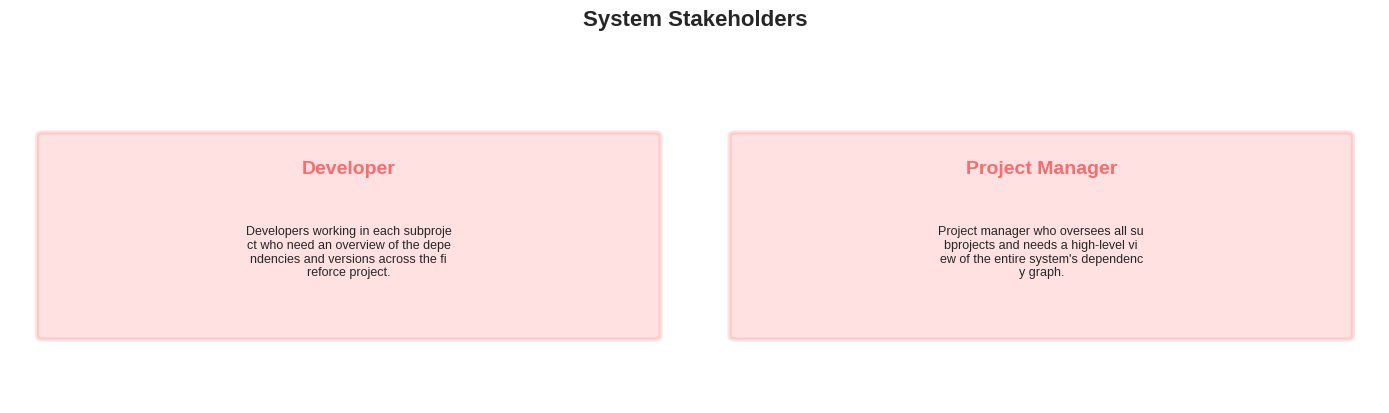

In [2]:
# Load stakeholders data
stakeholders_df = dataframe("stakeholders.json")
stakeholders_df['stakeholder_id'] = stakeholders_df['stakeholder'].apply(extract_id)

print("\n" + "="*80)
print("SYSTEM STAKEHOLDERS".center(80))
print("="*80 + "\n")

for idx, row in stakeholders_df.iterrows():
    print(f"{row['stakeholder_id'].upper().replace('-', ' ')}")
    print(f"   {row['stakeholder_desc']}")
    print()

# Create visual cards for stakeholders
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('System Stakeholders', fontsize=16, fontweight='bold', y=1.02)

for idx, (i, row) in enumerate(stakeholders_df.iterrows()):
    ax = axes[idx]
    ax.set_xlim(0, 10)
    ax.set_ylim(0, 10)
    ax.axis('off')
    
    # Draw card
    card = FancyBboxPatch((0.5, 2), 9, 6, 
                          boxstyle="round,pad=0.1", 
                          edgecolor=COLORS['stakeholder'],
                          facecolor=COLORS['stakeholder'],
                          alpha=0.2,
                          linewidth=3)
    ax.add_patch(card)
    
    # Add title
    title = row['stakeholder_id'].replace('-', ' ').title()
    ax.text(5, 7, title, ha='center', va='center', 
            fontsize=14, fontweight='bold', color=COLORS['stakeholder'])
    
    # Add description
    desc = '\n'.join([row['stakeholder_desc'][i:i+35] for i in range(0, len(row['stakeholder_desc']), 35)])
    ax.text(5, 4.5, desc, ha='center', va='center', 
            fontsize=9, wrap=True)

plt.tight_layout()
plt.show()

## 1.2 Requirements Analysis


                              SYSTEM REQUIREMENTS                               

 R1-VISUAL-OVERVIEW
   The dashboard must provide a visual overview of the dependencies and current releases for each sub-project.
   Expressed by: Developer, Project-Manager

 R2-FILE-COMPATIBILITY
   The dashboard must be compatible with dependency specification files in each subproject's repository.
   Expressed by: Developer

 R3-UP-TO-DATE
   The dashboard must have up-to-date versions and dependencies displayed in its graph.
   Expressed by: Developer, Project-Manager



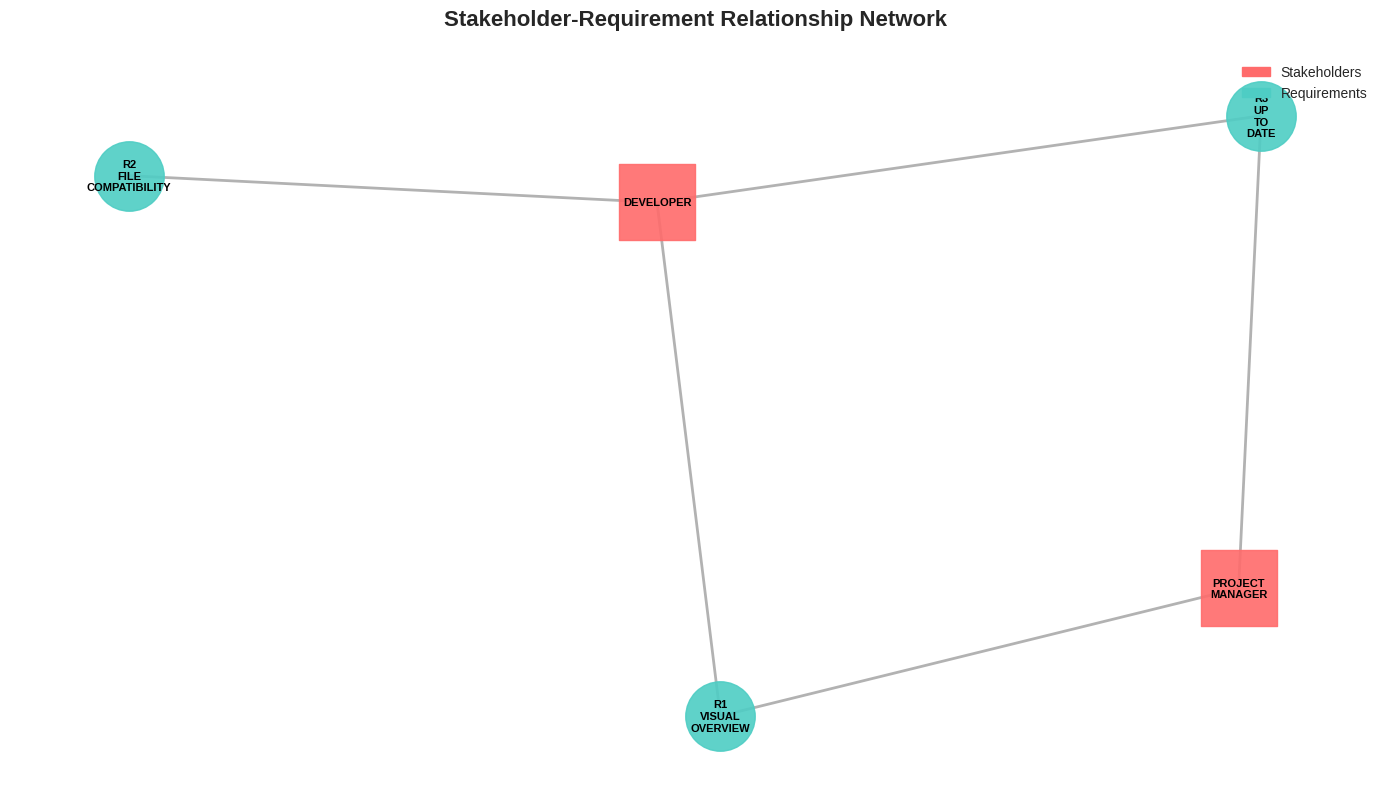

In [3]:
# Load requirements data
requirements_df = dataframe("requirements.json")
requirements_df['req_id'] = requirements_df['req'].apply(extract_id)
requirements_df['stakeholder_id'] = requirements_df['stakeholder_desc'].apply(
    lambda x: 'developer' if 'Developers' in x else 'project-manager'
)

unique_reqs = requirements_df.drop_duplicates(subset=['req_id'])[['req_id', 'req_desc']]

print("\n" + "="*80)
print("SYSTEM REQUIREMENTS".center(80))
print("="*80 + "\n")

for idx, row in unique_reqs.iterrows():
    stakeholders = requirements_df[requirements_df['req_id'] == row['req_id']]['stakeholder_id'].unique()
    print(f" {row['req_id'].upper()}")
    print(f"   {row['req_desc']}")
    print(f"   Expressed by: {', '.join(s.title() for s in stakeholders)}")
    print()

# Create requirement-stakeholder network graph
fig, ax = plt.subplots(figsize=(14, 8))

G = nx.Graph()

# Add nodes
for _, row in stakeholders_df.iterrows():
    G.add_node(row['stakeholder_id'], node_type='stakeholder')

for _, row in unique_reqs.iterrows():
    G.add_node(row['req_id'], node_type='requirement')

# Add edges
for _, row in requirements_df.iterrows():
    G.add_edge(row['stakeholder_id'], row['req_id'])

# Layout
pos = nx.spring_layout(G, k=2, iterations=50, seed=42)

# Draw nodes
stakeholder_nodes = [n for n, d in G.nodes(data=True) if d['node_type'] == 'stakeholder']
requirement_nodes = [n for n, d in G.nodes(data=True) if d['node_type'] == 'requirement']

nx.draw_networkx_nodes(G, pos, nodelist=stakeholder_nodes, 
                       node_color=COLORS['stakeholder'], 
                       node_size=3000, 
                       alpha=0.9, 
                       node_shape='s',
                       ax=ax)

nx.draw_networkx_nodes(G, pos, nodelist=requirement_nodes, 
                       node_color=COLORS['requirement'], 
                       node_size=2500, 
                       alpha=0.9,
                       ax=ax)

# Draw edges
nx.draw_networkx_edges(G, pos, edge_color='gray', width=2, alpha=0.6, ax=ax)

# Draw labels
labels = {n: n.replace('-', '\n').upper() for n in G.nodes()}
nx.draw_networkx_labels(G, pos, labels, font_size=8, font_weight='bold', ax=ax)

ax.set_title('Stakeholder-Requirement Relationship Network', 
             fontsize=16, fontweight='bold', pad=20)
ax.axis('off')

# Add legend
stakeholder_patch = mpatches.Patch(color=COLORS['stakeholder'], label='Stakeholders')
requirement_patch = mpatches.Patch(color=COLORS['requirement'], label='Requirements')
ax.legend(handles=[stakeholder_patch, requirement_patch], loc='upper right', fontsize=10)

plt.tight_layout()
plt.show()

##  1.3 Requirements Coverage Heatmap

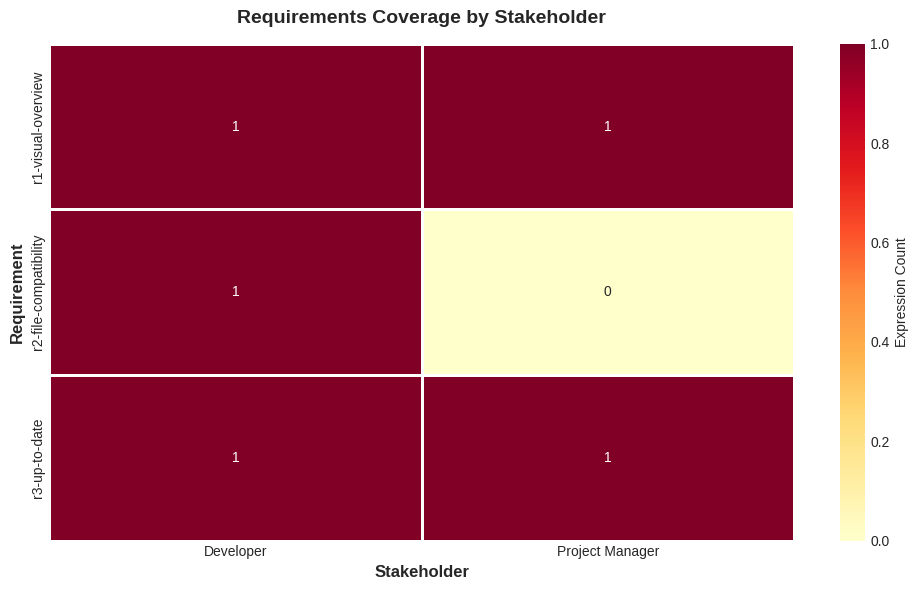


SUMMARY STATISTICS

Total Stakeholders:      2
Total Requirements:      3
Average Requirements:    2.5 per stakeholder



In [4]:
# Create pivot table for heatmap
pivot = requirements_df.groupby(['req_id', 'stakeholder_id']).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(pivot, annot=True, fmt='d', cmap='YlOrRd', 
            cbar_kws={'label': 'Expression Count'},
            linewidths=2, linecolor='white',
            ax=ax)

ax.set_title('Requirements Coverage by Stakeholder', 
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Stakeholder', fontsize=12, fontweight='bold')
ax.set_ylabel('Requirement', fontsize=12, fontweight='bold')
xticklabels = [label.get_text().replace('-', ' ').title() for label in ax.get_xticklabels()]
ax.set_xticklabels(xticklabels, rotation=0)

plt.tight_layout()
plt.show()

# Statistics
num_stakeholders = len(stakeholders_df)
num_requirements = len(unique_reqs)
reqs_per_stakeholder = requirements_df.groupby('stakeholder_id')['req_id'].nunique()

print("\nSUMMARY STATISTICS")
print("" * 50)
print(f"Total Stakeholders:      {num_stakeholders}")
print(f"Total Requirements:      {num_requirements}")
print(f"Average Requirements:    {reqs_per_stakeholder.mean():.1f} per stakeholder")
print()

---
# Part 2: Capabilities & Missions

## 2.1 Capability Architecture

In [5]:
# Load capabilities data
capabilities_df = dataframe("capabilities.json")
capabilities_df['cap_id'] = capabilities_df['cap'].apply(extract_id)
capabilities_df['req_id'] = capabilities_df['req'].apply(extract_id) if 'req' in capabilities_df.columns else None

# Separate capabilities and missions
caps_only = capabilities_df[capabilities_df['cap_id'].str.startswith('c', na=False)].copy()
missions_only = capabilities_df[capabilities_df['cap_id'].str.startswith('m', na=False)].copy()

print("\n" + "="*80)
print("SYSTEM CAPABILITIES".center(80))
print("="*80 + "\n")

for _, row in caps_only.drop_duplicates(subset=['cap_id']).iterrows():
    print(f"{row['cap_id'].upper()}")
    print(f"   {row['cap_desc']}")
    related_reqs = caps_only[caps_only['cap_id'] == row['cap_id']]['req_id'].dropna().unique()
    if len(related_reqs) > 0:
        print(f"    Derived from: {', '.join(related_reqs)}")
    print()

print("\n" + "="*80)
print("MISSIONS".center(80))
print("="*80 + "\n")

for _, row in missions_only.drop_duplicates(subset=['cap_id']).iterrows():
    print(f"{row['cap_id'].upper()}")
    print(f"   {row['cap_desc']}")
    print()


                              SYSTEM CAPABILITIES                               

C1-AUTHORIZATION
   Authorization: Server should gain authorization from GitHub App to access repository data.
    Derived from: r2-file-compatibility

C2-FETCH-CAPABILITY
   Fetch Capability: Server should be able to fetch from each of the subproject repositories to grab their current version and dependencies.
    Derived from: r2-file-compatibility, r3-up-to-date

C3-DASHBOARD-DISPLAY
   Dashboard Display: Dashboard should be able to take fetched dependencies and display them in a graph format.
    Derived from: r1-visual-overview


                                    MISSIONS                                    

M1-AT-A-GLANCE-OVERVIEW
   At a glance Overview: Needs clear visuals, displaying project connections and dependencies across the entire organization.

M2-EASY-INTEGRATION
   Easy Integration: Needs the ability to access files in subproject repositories without complex setup or manual configura

## 2.2 Capability Dependency Chain

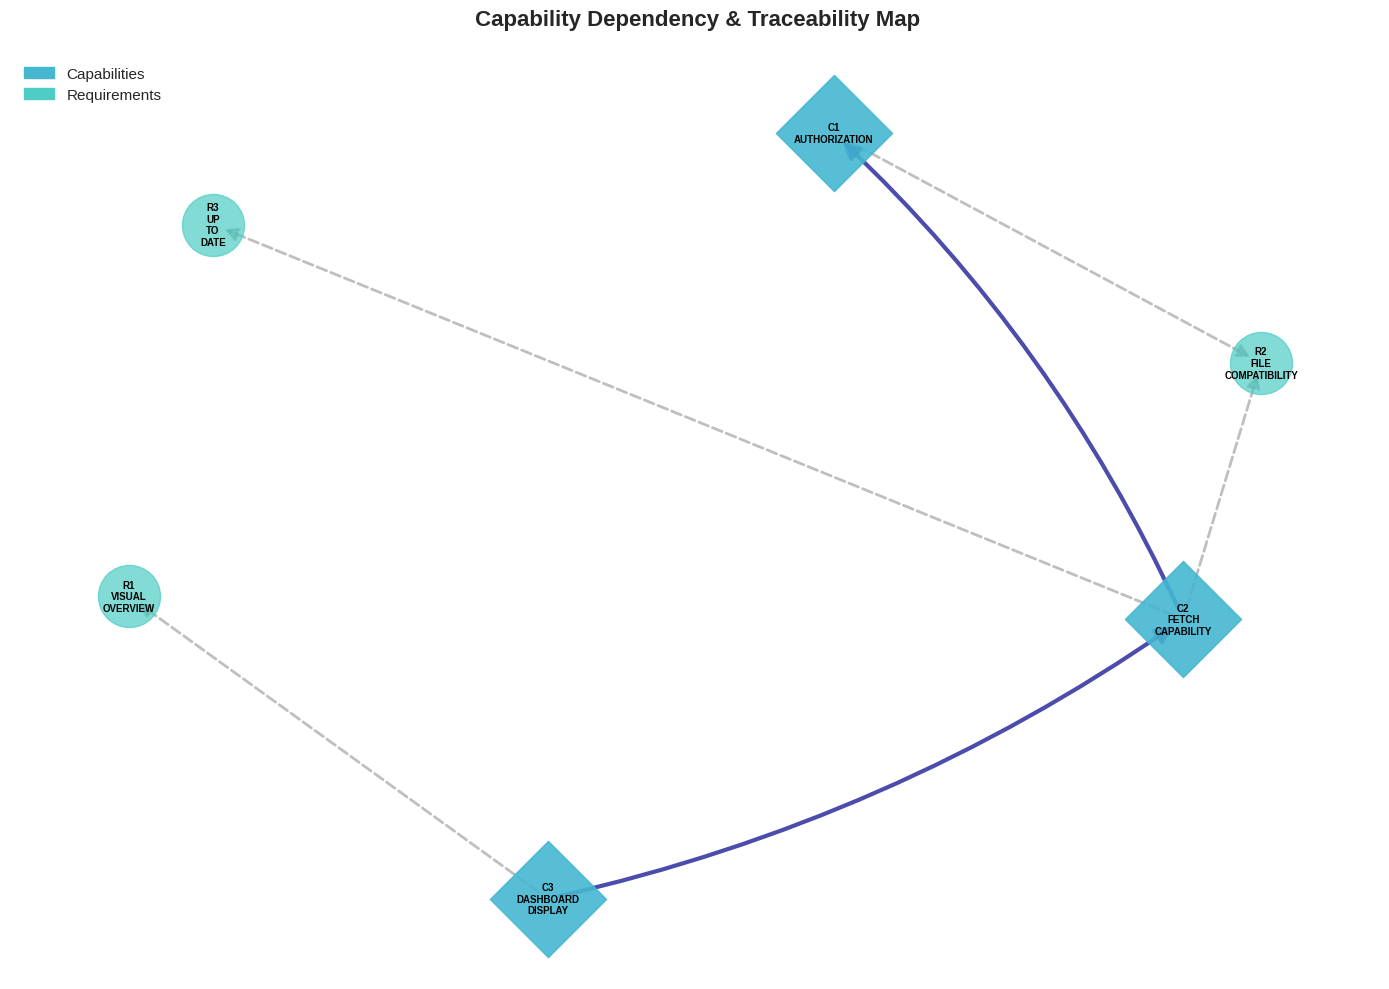

In [6]:
# Define capability dependencies manually (from capabilities.oml)
cap_dependencies = [
    ('c2-fetch-capability', 'c1-authorization'),
    ('c3-dashboard-display', 'c2-fetch-capability')
]

# Create directed graph
fig, ax = plt.subplots(figsize=(14, 10))

G = nx.DiGraph()

# Add capability nodes
for _, row in caps_only.drop_duplicates(subset=['cap_id']).iterrows():
    G.add_node(row['cap_id'], node_type='capability', desc=row['cap_desc'])

# Add requirement nodes
for _, row in unique_reqs.iterrows():
    G.add_node(row['req_id'], node_type='requirement', desc=row['req_desc'])

# Add edges: capabilities -> requirements (derivation)
for _, row in caps_only.iterrows():
    if pd.notna(row['req_id']):
        G.add_edge(row['cap_id'], row['req_id'], edge_type='derives')

# Add edges: capability dependencies
for src, tgt in cap_dependencies:
    G.add_edge(src, tgt, edge_type='requires')

# Hierarchical layout
pos = nx.spring_layout(G, k=3, iterations=50, seed=42)

# Separate node types
capability_nodes = [n for n, d in G.nodes(data=True) if d['node_type'] == 'capability']
requirement_nodes = [n for n, d in G.nodes(data=True) if d['node_type'] == 'requirement']

# Draw requirement nodes
nx.draw_networkx_nodes(G, pos, nodelist=requirement_nodes,
                       node_color=COLORS['requirement'],
                       node_size=2000,
                       alpha=0.7,
                       node_shape='o',
                       ax=ax)

# Draw capability nodes
nx.draw_networkx_nodes(G, pos, nodelist=capability_nodes,
                       node_color=COLORS['capability'],
                       node_size=3500,
                       alpha=0.9,
                       node_shape='D',
                       ax=ax)

# Draw edges with different styles
derives_edges = [(u, v) for u, v, d in G.edges(data=True) if d['edge_type'] == 'derives']
requires_edges = [(u, v) for u, v, d in G.edges(data=True) if d['edge_type'] == 'requires']

nx.draw_networkx_edges(G, pos, edgelist=derives_edges,
                       edge_color='gray',
                       style='dashed',
                       width=2,
                       alpha=0.5,
                       arrows=True,
                       arrowsize=20,
                       ax=ax)

nx.draw_networkx_edges(G, pos, edgelist=requires_edges,
                       edge_color='darkblue',
                       style='solid',
                       width=3,
                       alpha=0.7,
                       arrows=True,
                       arrowsize=25,
                       connectionstyle='arc3,rad=0.1',
                       ax=ax)

# Draw labels
labels = {n: n.replace('-', '\n').upper() for n in G.nodes()}
nx.draw_networkx_labels(G, pos, labels, font_size=7, font_weight='bold', ax=ax)

ax.set_title(' Capability Dependency & Traceability Map', 
             fontsize=16, fontweight='bold', pad=20)
ax.axis('off')

# Enhanced legend
legend_elements = [
    mpatches.Patch(color=COLORS['capability'], label='Capabilities'),
    mpatches.Patch(color=COLORS['requirement'], label='Requirements'),
    mpatches.FancyArrow(0, 0, 1, 0, width=0.3, color='darkblue', label='Requires'),
    mpatches.FancyArrow(0, 0, 1, 0, width=0.3, color='gray', linestyle='dashed', label='Derived From')
]
ax.legend(handles=legend_elements[:2], loc='upper left', fontsize=11)

plt.tight_layout()
plt.show()

## 2.3 Traceability Matrix

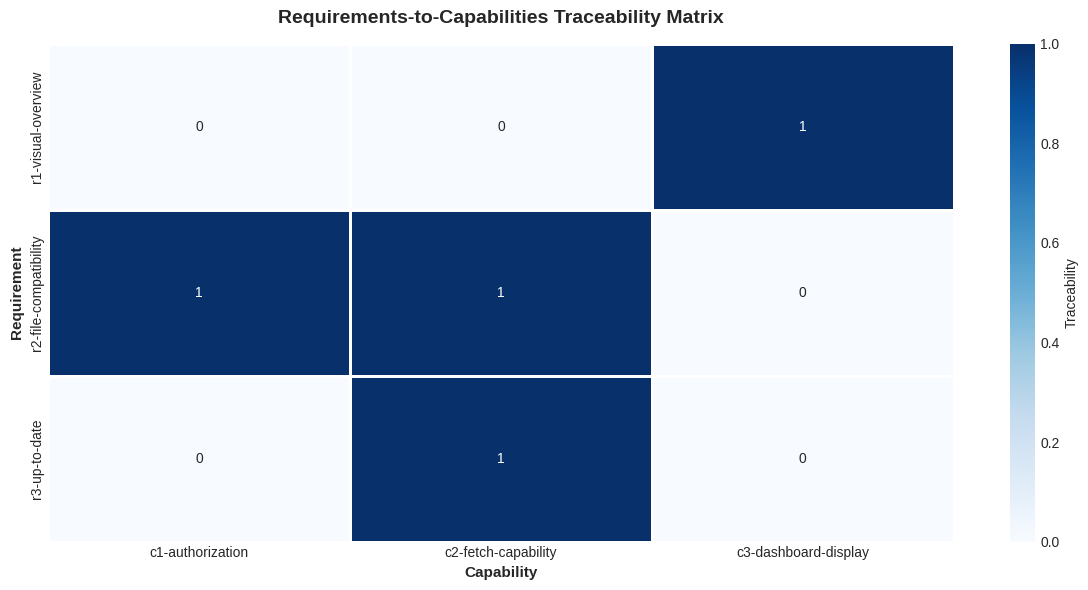

In [7]:
# Create requirement-to-capability traceability matrix
trace_data = []
for _, cap_row in caps_only.iterrows():
    if pd.notna(cap_row['req_id']):
        trace_data.append({
            'Requirement': cap_row['req_id'],
            'Capability': cap_row['cap_id'],
            'Value': 1
        })

trace_df = pd.DataFrame(trace_data)
if not trace_df.empty:
    trace_pivot = trace_df.pivot_table(index='Requirement', columns='Capability', 
                                       values='Value', fill_value=0, aggfunc='sum')
    
    fig, ax = plt.subplots(figsize=(12, 6))
    sns.heatmap(trace_pivot, annot=True, fmt='g', cmap='Blues',
                cbar_kws={'label': 'Traceability'},
                linewidths=2, linecolor='white',
                ax=ax)
    
    ax.set_title('Requirements-to-Capabilities Traceability Matrix',
                 fontsize=14, fontweight='bold', pad=15)
    ax.set_xlabel('Capability', fontsize=11, fontweight='bold')
    ax.set_ylabel('Requirement', fontsize=11, fontweight='bold')
    
    plt.tight_layout()
    plt.show()
else:
    print("No traceability data available.")

---
# Part 3: Entities & Architecture

## 3.1 System Entities


                                 SYSTEM ENTITIES                                

 COPILOT ENVIRONMENT
   The copilot-environment repository containing dependency specification files and version information.
    Involved in: c2-fetch-capability

 DASHBOARD
   The web dashboard that displays the dependency graph and version information.
    Involved in: c1-authorization, c2-fetch-capability, c3-dashboard-display

 FIRE CLOUD
   The fire-cloud repository containing dependency specification files and version information.
    Involved in: c2-fetch-capability

 FIRE WARDEN
   The fire-warden repository containing dependency specification files and version information.
    Involved in: c2-fetch-capability

 GITHUB APP
   The GitHub App that provides authorization and API access to repositories.
    Involved in: c1-authorization, c2-fetch-capability

 GITHUB ORGANIZATION
   The GitHub organization containing all subproject repositories.

 MISSION CONTROL
   The mission-control repository con

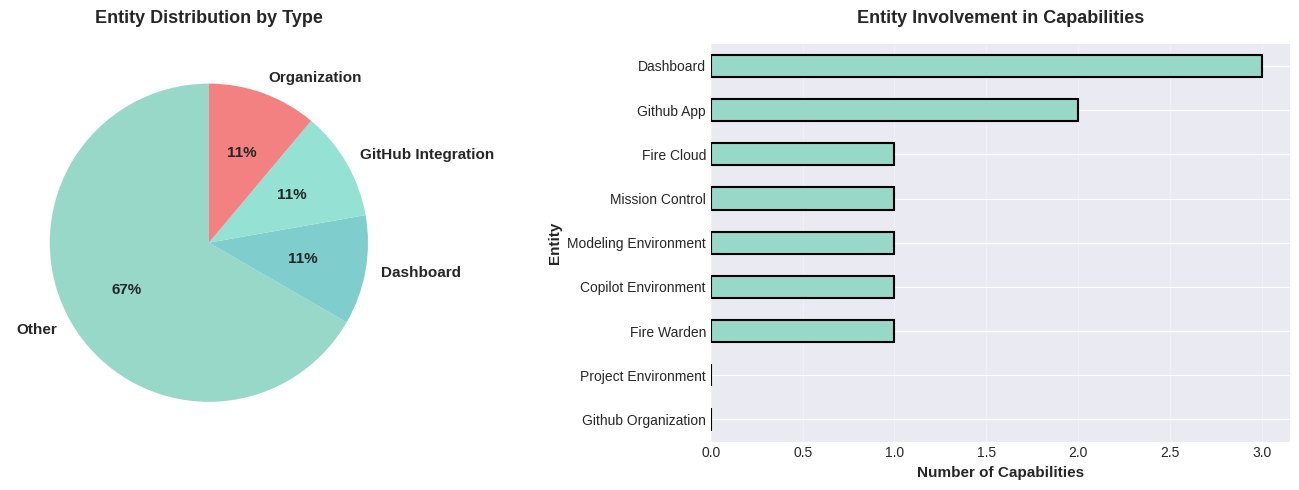

In [8]:
# Load entities data
entities_df = dataframe("entities.json")
entities_df['entity_id'] = entities_df['entity'].apply(extract_id)
entities_df['cap_id'] = entities_df['capability'].apply(extract_id) if 'capability' in entities_df.columns else None

unique_entities = entities_df.drop_duplicates(subset=['entity_id'])[['entity_id', 'entity_desc']]

print("\n" + "="*80)
print(" SYSTEM ENTITIES".center(80))
print("="*80 + "\n")

for _, row in unique_entities.iterrows():
    print(f" {row['entity_id'].upper().replace('-', ' ')}")
    print(f"   {row['entity_desc']}")
    
    # Show related capabilities
    related_caps = entities_df[entities_df['entity_id'] == row['entity_id']]['cap_id'].dropna().unique()
    if len(related_caps) > 0:
        print(f"    Involved in: {', '.join(related_caps)}")
    print()

# Count entities by type
entity_types = {
    'dashboard': 'Dashboard',
    'github-app': 'GitHub Integration',
    'github-organization': 'Organization',
    'subproject-repo-a': 'Repository',
    'subproject-repo-b': 'Repository'
}

type_counts = pd.Series([entity_types.get(e, 'Other') 
                         for e in unique_entities['entity_id']]).value_counts()

# Create entity distribution pie chart
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Pie chart
colors_pie = [COLORS['entity'], '#7FCDCD', '#95E1D3', '#F38181', '#EAFFD0']
ax1.pie(type_counts.values, labels=type_counts.index, autopct='%1.0f%%',
        colors=colors_pie, startangle=90, textprops={'fontsize': 11, 'fontweight': 'bold'})
ax1.set_title('Entity Distribution by Type', fontsize=13, fontweight='bold', pad=15)

# Bar chart of capability involvement
cap_involvement = entities_df.groupby('entity_id')['cap_id'].count().sort_values(ascending=True)
cap_involvement.plot(kind='barh', ax=ax2, color=COLORS['entity'], edgecolor='black', linewidth=1.5)
ax2.set_title('Entity Involvement in Capabilities', fontsize=13, fontweight='bold', pad=15)
ax2.set_xlabel('Number of Capabilities', fontsize=11, fontweight='bold')
ax2.set_ylabel('Entity', fontsize=11, fontweight='bold')
ax2.grid(axis='x', alpha=0.3)

# Format y-axis labels
ax2.set_yticklabels([label.get_text().replace('-', ' ').title() 
                     for label in ax2.get_yticklabels()])

plt.tight_layout()
plt.show()

## 3.2 Entity-Capability Architecture Diagram

In [9]:
# Create entity-capability relationship graphfig, ax = plt.subplots(figsize=(16, 10))G = nx.Graph()# Filter entities to show only a subset for clarityDISPLAY_REPOS = ['mission-control', 'copilot-environment']OTHER_REPOS_COUNT = 0# Add nodes - filter entity nodes to only show subsetfor _, row in unique_entities.iterrows():    entity_id = row['entity_id']    # Always show non-repo entities (dashboard, github-app, etc)    is_repo = any(repo in entity_id for repo in ['fire-warden', 'mission-control', 'modeling-environment',                                                    'copilot-environment', 'fire-cloud', 'project-environment'])        if not is_repo or entity_id in DISPLAY_REPOS:        G.add_node(row['entity_id'], node_type='entity', desc=row['entity_desc'])    elif is_repo and entity_id not in DISPLAY_REPOS:        OTHER_REPOS_COUNT += 1# Add a special "other repos" nodeif OTHER_REPOS_COUNT > 0:    G.add_node('other-repos', node_type='entity', desc=f'{OTHER_REPOS_COUNT} other repositories')for _, row in caps_only.drop_duplicates(subset=['cap_id']).iterrows():    G.add_node(row['cap_id'], node_type='capability', desc=row['cap_desc'])# Add edges - including edges to "other repos" nodefor _, row in entities_df.iterrows():    if pd.notna(row['cap_id']):        entity_id = row['entity_id']        # Check if this entity should be shown        is_repo = any(repo in entity_id for repo in ['fire-warden', 'mission-control', 'modeling-environment',                                                        'copilot-environment', 'fire-cloud', 'project-environment'])                if entity_id in G.nodes():            G.add_edge(entity_id, row['cap_id'])        elif is_repo and entity_id not in DISPLAY_REPOS and 'other-repos' in G.nodes():            # Route hidden repo edges to the "other repos" node            G.add_edge('other-repos', row['cap_id'])# Bipartite layoutentity_nodes = [n for n, d in G.nodes(data=True) if d['node_type'] == 'entity']capability_nodes = [n for n, d in G.nodes(data=True) if d['node_type'] == 'capability']pos = {}# Position entities on the leftfor i, node in enumerate(entity_nodes):    pos[node] = (0, i * 2)# Position capabilities on the rightfor i, node in enumerate(capability_nodes):    pos[node] = (3, i * 2.5)# Draw entity nodes with different styles for "other repos"regular_entities = [n for n in entity_nodes if n != 'other-repos']other_repos_node = ['other-repos'] if 'other-repos' in entity_nodes else []nx.draw_networkx_nodes(G, pos, nodelist=regular_entities,                       node_color=COLORS['entity'],                       node_size=4000,                       alpha=0.9,                       node_shape='s',                       ax=ax)# Draw "other repos" with different styleif other_repos_node:    nx.draw_networkx_nodes(G, pos, nodelist=other_repos_node,                           node_color=COLORS['entity'],                           node_size=4000,                           alpha=0.5,                           node_shape='s',                           edgecolors='gray',                           linewidths=3,                           ax=ax)# Draw capability nodesnx.draw_networkx_nodes(G, pos, nodelist=capability_nodes,                       node_color=COLORS['capability'],                       node_size=3500,                       alpha=0.9,                       node_shape='D',                       ax=ax)# Draw edgesnx.draw_networkx_edges(G, pos, edge_color='gray', width=2, alpha=0.5, ax=ax)# Draw labels with better formatting for "other repos"labels = {}for n in G.nodes():    if n == 'other-repos':        labels[n] = f'... {OTHER_REPOS_COUNT} more\nrepositories'    else:        labels[n] = n.replace('-', '\n').upper()nx.draw_networkx_labels(G, pos, labels, font_size=8, font_weight='bold', ax=ax)ax.set_title(' Entity-Capability Architecture Map (Simplified View)',              fontsize=16, fontweight='bold', pad=20)ax.axis('off')# Add section labelsax.text(-0.5, len(entity_nodes), 'ENTITIES',         fontsize=14, fontweight='bold', color=COLORS['entity'],        bbox=dict(boxstyle='round', facecolor='white', edgecolor=COLORS['entity'], linewidth=2))ax.text(2.5, len(capability_nodes), 'CAPABILITIES',         fontsize=14, fontweight='bold', color=COLORS['capability'],        bbox=dict(boxstyle='round', facecolor='white', edgecolor=COLORS['capability'], linewidth=2))# Add note about filtered viewax.text(1.5, -1, f'Note: Showing {len(DISPLAY_REPOS)} sample repositories for clarity',         fontsize=10, ha='center', style='italic', color='gray')plt.tight_layout()plt.show()

---
# Part 4: Process Flows & Data Flows

## 4.1 Process Overview

In [10]:
# Load processes data
processes_df = dataframe("processes.json")
processes_df['process_id'] = processes_df['process'].apply(extract_id)
processes_df['cap_id'] = processes_df['capability'].apply(extract_id) if 'capability' in processes_df.columns else None

unique_processes = processes_df.drop_duplicates(subset=['process_id'])[['process_id', 'process_desc', 'cap_id']]

print("\n" + "="*80)
print("SYSTEM PROCESSES".center(80))
print("="*80 + "\n")

for _, row in unique_processes.iterrows():
    print(f"{row['process_id'].upper()}")
    print(f"   {row['process_desc']}")
    if pd.notna(row['cap_id']):
        print(f"   Describes capability: {row['cap_id']}")
    print()


                                SYSTEM PROCESSES                                

P1-GET-INSTALLATION-TOKEN
   Process to obtain GitHub App installation token for API access.
   Describes capability: c1-authorization

P2-FETCH-DEPENDENCIES
   Process to fetch current version and dependencies from all subproject repositories.
   Describes capability: c2-fetch-capability

P3-DISPLAY-DASHBOARD
   Process to display fetched dependencies and versions in a graph format.
   Describes capability: c3-dashboard-display



## 4.2 Data Flow Visualization


Total Data Flows: 29
Across 3 processes



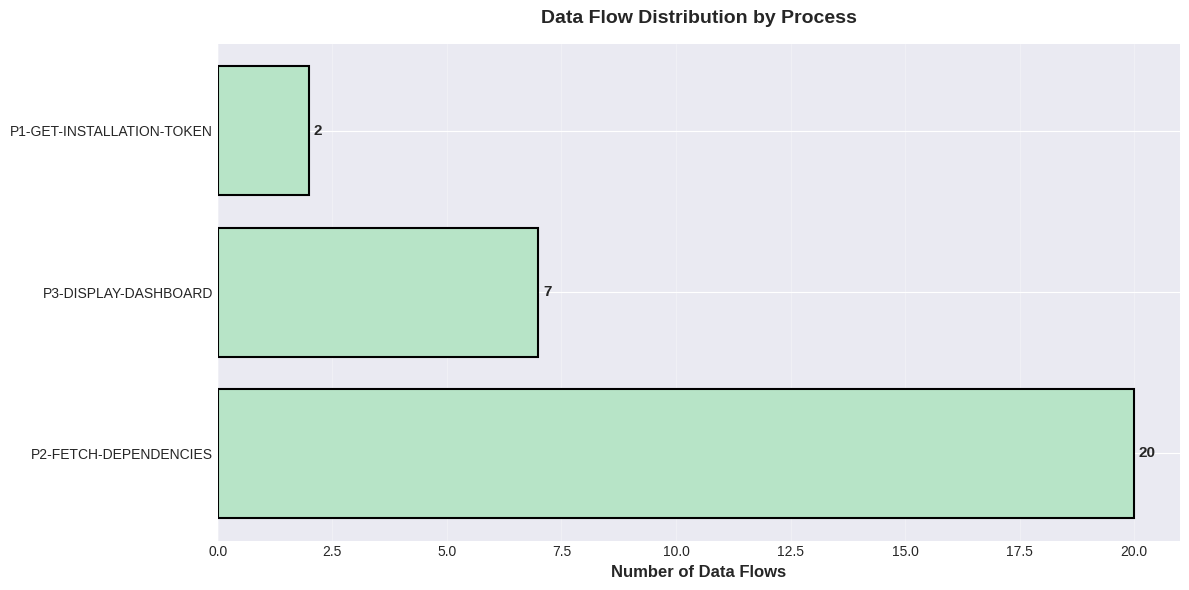


                                SAMPLE DATA FLOWS                               

Process: P1-GET-INSTALLATION-TOKEN

  • Token request flows from dashboard to GitHub App.
    Data: Installation token request payload.
  • Installation token flows from GitHub App to dashboard.
    Data: GitHub App installation token for API access.



In [11]:
# Load dataflows
dataflows_df = dataframe("dataflows.json")
dataflows_df['dataflow_id'] = dataflows_df['dataflow'].apply(extract_id)
dataflows_df['process_id'] = dataflows_df['process'].apply(extract_id)
dataflows_df['data_id'] = dataflows_df['data'].apply(extract_id) if 'data' in dataflows_df.columns else None

print(f"\nTotal Data Flows: {len(dataflows_df)}")
print(f"Across {dataflows_df['process_id'].nunique()} processes\n")

# Data flows by process
flows_by_process = dataflows_df.groupby('process_id').size().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(range(len(flows_by_process)), flows_by_process.values, 
               color=COLORS['dataflow'], edgecolor='black', linewidth=1.5)

# Add value labels
for i, (idx, value) in enumerate(flows_by_process.items()):
    ax.text(value + 0.1, i, str(value), va='center', fontweight='bold', fontsize=11)

ax.set_yticks(range(len(flows_by_process)))
ax.set_yticklabels([p.upper() for p in flows_by_process.index])
ax.set_xlabel('Number of Data Flows', fontsize=12, fontweight='bold')
ax.set_title('Data Flow Distribution by Process', fontsize=14, fontweight='bold', pad=15)
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

# Show some example data flows
print("\n" + "="*80)
print(" SAMPLE DATA FLOWS".center(80))
print("="*80 + "\n")

for process_id in unique_processes['process_id'].head(1):
    process_flows = dataflows_df[dataflows_df['process_id'] == process_id]
    print(f"Process: {process_id.upper()}")
    print("" * 80)
    for _, flow in process_flows.head(3).iterrows():
        print(f"  • {flow['dataflow_desc']}")
        if pd.notna(flow.get('data_desc')):
            print(f"    Data: {flow['data_desc']}")
    print()

## 4.3 Process-to-Capability Mapping

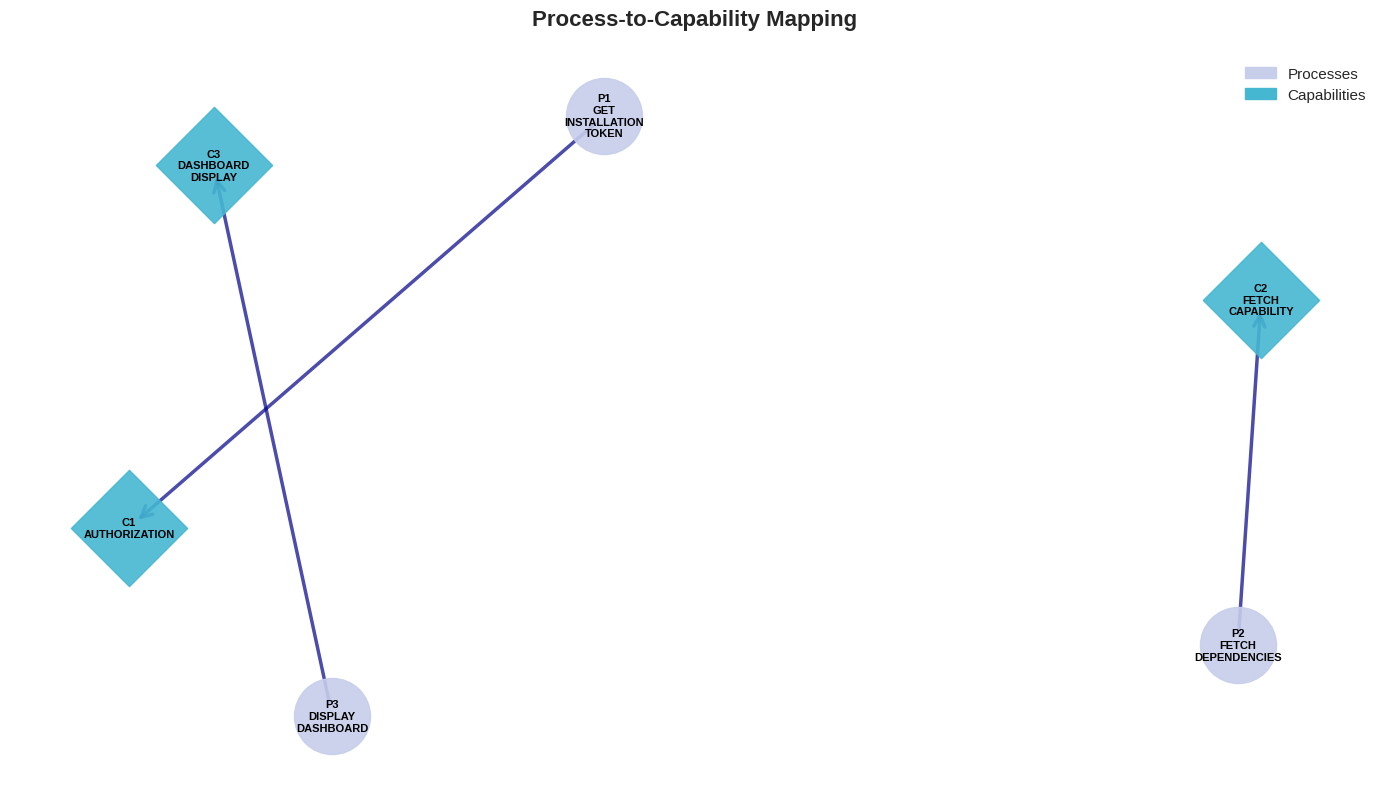

In [12]:
# Create process-capability network
fig, ax = plt.subplots(figsize=(14, 8))

G = nx.DiGraph()

# Add nodes
for _, row in unique_processes.iterrows():
    G.add_node(row['process_id'], node_type='process')

for _, row in caps_only.drop_duplicates(subset=['cap_id']).iterrows():
    G.add_node(row['cap_id'], node_type='capability')

# Add edges
for _, row in unique_processes.iterrows():
    if pd.notna(row['cap_id']):
        G.add_edge(row['process_id'], row['cap_id'])

# Layout
pos = nx.spring_layout(G, k=2, iterations=50, seed=42)

# Draw nodes
process_nodes = [n for n, d in G.nodes(data=True) if d['node_type'] == 'process']
capability_nodes = [n for n, d in G.nodes(data=True) if d['node_type'] == 'capability']

nx.draw_networkx_nodes(G, pos, nodelist=process_nodes,
                       node_color=COLORS['process'],
                       node_size=3000,
                       alpha=0.9,
                       node_shape='o',
                       ax=ax)

nx.draw_networkx_nodes(G, pos, nodelist=capability_nodes,
                       node_color=COLORS['capability'],
                       node_size=3500,
                       alpha=0.9,
                       node_shape='D',
                       ax=ax)

# Draw edges
nx.draw_networkx_edges(G, pos, edge_color='darkblue', width=2.5, alpha=0.7,
                       arrows=True, arrowsize=20, arrowstyle='->', ax=ax)

# Draw labels
labels = {n: n.replace('-', '\n').upper() for n in G.nodes()}
nx.draw_networkx_labels(G, pos, labels, font_size=8, font_weight='bold', ax=ax)

ax.set_title('Process-to-Capability Mapping', 
             fontsize=16, fontweight='bold', pad=20)
ax.axis('off')

# Legend
legend_elements = [
    mpatches.Patch(color=COLORS['process'], label='Processes'),
    mpatches.Patch(color=COLORS['capability'], label='Capabilities')
]
ax.legend(handles=legend_elements, loc='upper right', fontsize=11)

plt.tight_layout()
plt.show()

---
# Part 5: PlantUML Diagrams

## 5.1 Complete System Architecture (PlantUML)

In [13]:
# Generate comprehensive PlantUML diagram
uml = "@startuml\n"
uml += "skinparam backgroundColor #FAFAFA\n"
uml += "skinparam shadowing false\n"
uml += "skinparam ArrowColor #333333\n"
uml += "skinparam objectBorderColor #333333\n"
uml += "skinparam objectBackgroundColor #E8F4F8\n"
uml += "\n"

# Add requirements
uml += "' Requirements\n"
for _, row in unique_reqs.iterrows():
    req_id = row['req_id'].replace('-', '_')
    uml += f'rectangle "{row["req_id"]}" as {req_id} #4ECDC4\n'

uml += "\n"

# Add capabilities
uml += "' Capabilities\n"
for _, row in caps_only.drop_duplicates(subset=['cap_id']).iterrows():
    cap_id = row['cap_id'].replace('-', '_')
    uml += f'component "{row["cap_id"]}" as {cap_id} #45B7D1\n'

uml += "\n"

# Add entities
uml += "' Entities\n"
for _, row in unique_entities.iterrows():
    entity_id = row['entity_id'].replace('-', '_')
    uml += f'database "{row["entity_id"]}" as {entity_id} #98D8C8\n'

uml += "\n"

# Add relationships: capabilities -> requirements
uml += "' Capability derives from Requirement\n"
for _, row in caps_only.iterrows():
    if pd.notna(row['req_id']):
        cap_id = row['cap_id'].replace('-', '_')
        req_id = row['req_id'].replace('-', '_')
        uml += f'{cap_id} ..> {req_id} : derives from\n'

uml += "\n"

# Add relationships: capability dependencies
uml += "' Capability Dependencies\n"
for src, tgt in cap_dependencies:
    src_id = src.replace('-', '_')
    tgt_id = tgt.replace('-', '_')
    uml += f'{src_id} --> {tgt_id} : requires\n'

uml += "\n"

# Add relationships: entities -> capabilities
uml += "' Entity involves Capability\n"
for _, row in entities_df.iterrows():
    if pd.notna(row['cap_id']):
        entity_id = row['entity_id'].replace('-', '_')
        cap_id = row['cap_id'].replace('-', '_')
        uml += f'{entity_id} ..> {cap_id} : supports\n'

uml += "\n@enduml\n"

# Display the diagram
print("Generating Complete System Architecture Diagram...\n")
diagram(uml)

Generating Complete System Architecture Diagram...



![Alt text](http://www.plantuml.com/plantuml/img/fPNBSXen44NtynKgMB2IgtYaGhnmsURn0Va1LICre5Ye5Ka3HRu-DG-m1eGX5LYf-vvBIwCxl8O8FfOxKuGFRHrusB4Lo8-DfzAg6HdohBzygxw98cn1qK7R3Lk32PXqthodGukDwq_IfDKlbF6Tl49_HtCvmcAwd2odHJ5WF_5tgJtkqCPGU9GHxCOWw_aXt-jGWk6qHx_NUEWn2CmFHLCMfpBhJnQp-MpIWKTyhGroIJi7KQ-qqV7Oy2DHTKIdaxKOyzBnI5n1n0OTYzA9IAAgd95Ym6RWe3RI68hAc2pQo7fooA6CM_Bw3qHDjdQHGz4filxas_lt-R03ZlWQeznoUN9kXfSZKTV5PpsBZxc2i5qHUCML3iv0ou_5kI7QnjcW6B25ZSqc54HOGK3Ma-IqeSZHxhKdMpscnggfYwJE-Z-cy-bicj3dNwkPyogZN6kFN1eg6scr5FNoblO0Ng7z53VhZ7gZuxPSSN2k5ZTB0SxTrfBVW4qVMWkbzGozqo5eiboIZPvCJROrqTPo52aqscwkZlZKk7F6pbCLiIkyhMVfzD8UcKAlznZOsjCkpMDnTLUVdbvk9EYvurBaRkh_mvq0NaAvkrrJrs-C2xHx6dDqQ1LQMQSvCmhdBzSfVcQ-ERYGdwI6CcO9TmhWaMcx9rEDzpbMaGjSjRsyQIYT8n-h99yoLuklnxwb_2VRt8uJTPBc1xpJE3yWJm9zRukNqg-DBwFx29ABx0DSyOfMLV_QVm4=)

##  5.2 Capability Dependency Diagram (PlantUML)

---
# Part 6: Summary Dashboard

In [14]:
# Generate capability dependency diagram
uml = "@startuml\n"
uml += "skinparam componentStyle rectangle\n"
uml += "skinparam backgroundColor #FAFAFA\n"
uml += "skinparam component {\n"
uml += "  BackgroundColor #45B7D1\n"
uml += "  BorderColor #333333\n"
uml += "  ArrowColor #333333\n"
uml += "}\n"
uml += "\n"

# Add capabilities
for _, row in caps_only.drop_duplicates(subset=['cap_id']).iterrows():
    cap_id = row['cap_id'].replace('-', '_')
    label = row['cap_id'].replace('-', '\\n')
    uml += f'component "{label}" as {cap_id}\n'

uml += "\n"

# Add dependencies
for src, tgt in cap_dependencies:
    src_id = src.replace('-', '_')
    tgt_id = tgt.replace('-', '_')
    uml += f'{src_id} --> {tgt_id}\n'

uml += "\n@enduml\n"

print("Generating Capability Dependency Chain...\n")
diagram(uml)

Generating Capability Dependency Chain...



![Alt text](http://www.plantuml.com/plantuml/img/RP51QyCm38Nl_XMYFVUGfcEtqNPZVs1NWr5ijp5rf20xZ6xqlvUqOLsAfTjxxti8j4qP9GzTLEaKg4V13YntFPEd_9NFqODucv6EqV-BD6XFH-61t3j75bX-xiOjbS2l0jW_vpSl-zUFQdHOd9T9hM-Z07OY_3qNBqezEXUsqeH3Rbd23-R0j01CO2ip4sV4MjF1PzjgijXZ4sB8vpkrDZV3FFGPM6jocDg6KPmc5r8VSI9hy-UOoL2gq0UhrLlXkW9-JnOkKbjFRdpK5G==)

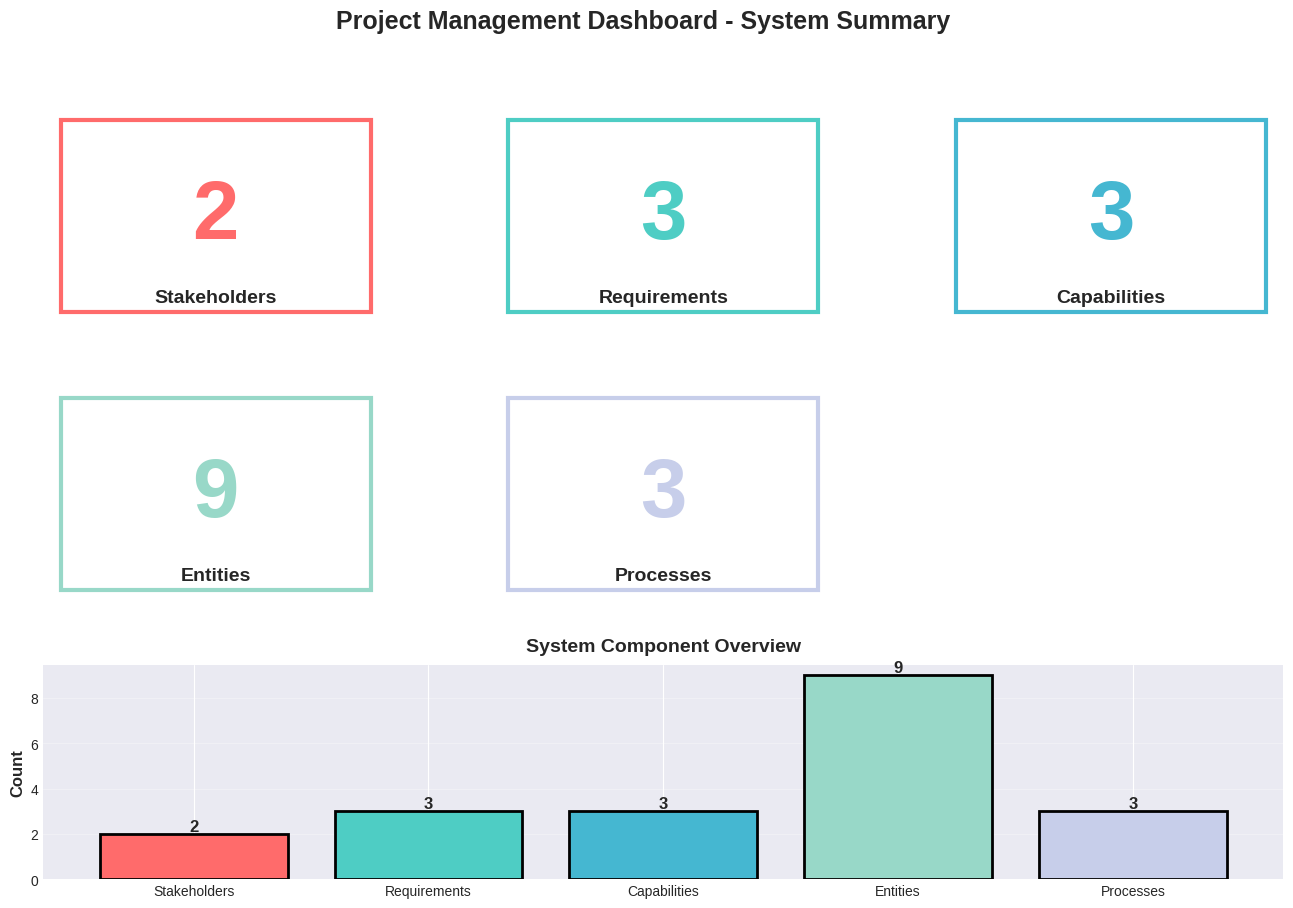


                          SYSTEM ARCHITECTURE SUMMARY                           

The Project Management Dashboard system comprises:

  2 Stakeholders driving the system requirements
  3 Requirements defining system needs
  3 Capabilities delivering functionality
  9 Entities implementing the system
  3 Processes orchestrating behavior
  29 Data flows connecting components

Complete architecture visualized successfully!



In [15]:
# Create comprehensive summary dashboard
fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

# Title
fig.suptitle('Project Management Dashboard - System Summary', 
             fontsize=18, fontweight='bold', y=0.98)

# 1. Stakeholder count
ax1 = fig.add_subplot(gs[0, 0])
ax1.text(0.5, 0.5, str(len(stakeholders_df)), 
         ha='center', va='center', fontsize=60, fontweight='bold', color=COLORS['stakeholder'])
ax1.text(0.5, 0.1, 'Stakeholders', ha='center', fontsize=14, fontweight='bold')
ax1.axis('off')
ax1.add_patch(Rectangle((0.05, 0.05), 0.9, 0.9, fill=False, edgecolor=COLORS['stakeholder'], linewidth=3))

# 2. Requirement count
ax2 = fig.add_subplot(gs[0, 1])
ax2.text(0.5, 0.5, str(len(unique_reqs)), 
         ha='center', va='center', fontsize=60, fontweight='bold', color=COLORS['requirement'])
ax2.text(0.5, 0.1, 'Requirements', ha='center', fontsize=14, fontweight='bold')
ax2.axis('off')
ax2.add_patch(Rectangle((0.05, 0.05), 0.9, 0.9, fill=False, edgecolor=COLORS['requirement'], linewidth=3))

# 3. Capability count
ax3 = fig.add_subplot(gs[0, 2])
ax3.text(0.5, 0.5, str(len(caps_only.drop_duplicates(subset=['cap_id']))), 
         ha='center', va='center', fontsize=60, fontweight='bold', color=COLORS['capability'])
ax3.text(0.5, 0.1, 'Capabilities', ha='center', fontsize=14, fontweight='bold')
ax3.axis('off')
ax3.add_patch(Rectangle((0.05, 0.05), 0.9, 0.9, fill=False, edgecolor=COLORS['capability'], linewidth=3))

# 4. Entity count
ax4 = fig.add_subplot(gs[1, 0])
ax4.text(0.5, 0.5, str(len(unique_entities)), 
         ha='center', va='center', fontsize=60, fontweight='bold', color=COLORS['entity'])
ax4.text(0.5, 0.1, 'Entities', ha='center', fontsize=14, fontweight='bold')
ax4.axis('off')
ax4.add_patch(Rectangle((0.05, 0.05), 0.9, 0.9, fill=False, edgecolor=COLORS['entity'], linewidth=3))

# 5. Process count
ax5 = fig.add_subplot(gs[1, 1])
ax5.text(0.5, 0.5, str(len(unique_processes)), 
         ha='center', va='center', fontsize=60, fontweight='bold', color=COLORS['process'])
ax5.text(0.5, 0.1, 'Processes', ha='center', fontsize=14, fontweight='bold')
ax5.axis('off')
ax5.add_patch(Rectangle((0.05, 0.05), 0.9, 0.9, fill=False, edgecolor=COLORS['process'], linewidth=3))


# 7. Requirements per stakeholder
ax7 = fig.add_subplot(gs[2, :])
summary_data = pd.DataFrame({
    'Category': ['Stakeholders', 'Requirements', 'Capabilities', 'Entities', 'Processes'],
    'Count': [
        len(stakeholders_df),
        len(unique_reqs),
        len(caps_only.drop_duplicates(subset=['cap_id'])),
        len(unique_entities),
        len(unique_processes)
    ]
})

colors_list = [COLORS['stakeholder'], COLORS['requirement'], COLORS['capability'], 
               COLORS['entity'], COLORS['process']]
bars = ax7.bar(summary_data['Category'], summary_data['Count'], 
               color=colors_list, edgecolor='black', linewidth=2)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    ax7.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height)}',
            ha='center', va='bottom', fontweight='bold', fontsize=12)

ax7.set_ylabel('Count', fontsize=12, fontweight='bold')
ax7.set_title('System Component Overview', fontsize=14, fontweight='bold', pad=10)
ax7.grid(axis='y', alpha=0.3)

plt.show()

# Print final summary
print("\n" + "="*80)
print("SYSTEM ARCHITECTURE SUMMARY".center(80))
print("="*80)
print(f"""
The Project Management Dashboard system comprises:
  
  {len(stakeholders_df)} Stakeholders driving the system requirements
  {len(unique_reqs)} Requirements defining system needs
  {len(caps_only.drop_duplicates(subset=['cap_id']))} Capabilities delivering functionality
  {len(unique_entities)} Entities implementing the system
  {len(unique_processes)} Processes orchestrating behavior
  {len(dataflows_df)} Data flows connecting components

Complete architecture visualized successfully!
""")
print("="*80)